In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 354kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.95MB/s]

Training samples: 60000
Test samples: 10000


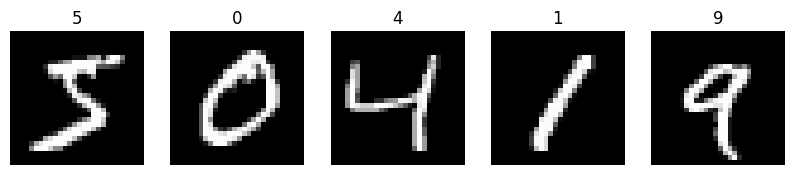

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i in range(5):
    image, label = train_dataset[i]

    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(label)
    axes[i].axis("off")

plt.show()

In [ ]:
class Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3
        )

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3
        )

        self.dropout1 = nn.Dropout(0.25)

        self.dropout2 = nn.Dropout(0.5)

        self.fc1 = nn.Linear(9216, 128)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.conv1(x)
        x = torch.relu(x)

        x = self.conv2(x)
        x = torch.relu(x)

        x = torch.max_pool2d(x, 2)

        x = self.dropout1(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.dropout2(x)

        x = self.fc2(x)

        return x

In [ ]:
model = Net().to(device)

print(model)

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# Task 1 :

1.   Loop Pattern - zero gradients then forward pass after which you compute loss and backward pass and update weights after
2.   Difference between NLL Loss and CrossEntropy Loss - CrossEntropy Loss is preffered because it has both NLL and log softmax which is preffered for multiclass classification like MNIST
3. Optimizers - SGD shows slow convergence whereas Adam exihibits faster convergence and hence becomes the default choice here even though it uses up more memory
4. Rate Schedulers - These gradually reduce the learning rate after the optimizers update.







In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=1,
    gamma=0.7
)

In [ ]:
def train(model,
          device,
          train_loader,
          optimizer,
          criterion,
          epoch):

    model.train()

    running_loss = 0

    for batch_idx, (data, target) in enumerate(train_loader):

        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = model(data)

        loss = criterion(output, target)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 100 == 0:

            print(
                f"Epoch {epoch} "
                f"[{batch_idx}/{len(train_loader)}] "
                f"Loss: {loss.item():.4f}"
            )

    avg_loss = running_loss / len(train_loader)

    return avg_loss

# task 2


1.   model.eval() - this disables BatchNorm and dropout while testing to truly evaluate accuaracy
2.   torch.no_grad() - this diables gradient calculation which reduces menory consumption
3. Overfitting - the model memorizes the training set so closely that when tested the predictions fail even though it does well on the training set



In [ ]:
def test(model,
         device,
         test_loader,
         criterion):

    model.eval()

    test_loss = 0
    correct = 0

    with torch.no_grad():

        for data, target in test_loader:

            data = data.to(device)
            target = target.to(device)

            output = model(data)

            loss = criterion(output, target)

            test_loss += loss.item()

            prediction = output.argmax(dim=1)

            correct += prediction.eq(target).sum().item()

    avg_loss = test_loss / len(test_loader)

    accuracy = 100 * correct / len(test_loader.dataset)

    print(
        f"Test Loss: {avg_loss:.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

    return avg_loss, accuracy

In [ ]:
epochs = 5

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(1, epochs + 1):

    train_loss = train(
        model,
        device,
        train_loader,
        optimizer,
        criterion,
        epoch
    )

    test_loss, test_acc = test(
        model,
        device,
        test_loader,
        criterion
    )

    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print("-" * 50)

Epoch 1 [0/938] Loss: 0.0692
Epoch 1 [100/938] Loss: 0.1340
Epoch 1 [200/938] Loss: 0.1112
Epoch 1 [300/938] Loss: 0.1363
Epoch 1 [400/938] Loss: 0.0369
Epoch 1 [500/938] Loss: 0.1355
Epoch 1 [600/938] Loss: 0.1719
Epoch 1 [700/938] Loss: 0.0642
Epoch 1 [800/938] Loss: 0.0110
Epoch 1 [900/938] Loss: 0.0450
Test Loss: 0.0418 | Accuracy: 98.64%
--------------------------------------------------
Epoch 2 [0/938] Loss: 0.0495
Epoch 2 [100/938] Loss: 0.0318
Epoch 2 [200/938] Loss: 0.0642
Epoch 2 [300/938] Loss: 0.0406
Epoch 2 [400/938] Loss: 0.0995
Epoch 2 [500/938] Loss: 0.0500
Epoch 2 [600/938] Loss: 0.0267
Epoch 2 [700/938] Loss: 0.0898
Epoch 2 [800/938] Loss: 0.0591
Epoch 2 [900/938] Loss: 0.0765
Test Loss: 0.0309 | Accuracy: 99.09%
--------------------------------------------------
Epoch 3 [0/938] Loss: 0.0038
Epoch 3 [100/938] Loss: 0.0853
Epoch 3 [200/938] Loss: 0.0559
Epoch 3 [300/938] Loss: 0.0399
Epoch 3 [400/938] Loss: 0.0787
Epoch 3 [500/938] Loss: 0.0167
Epoch 3 [600/938] Loss: 

# task 3


1.   Difference between saving the full model and using state_dict


*   full.model() - this requires the least  amount of code however serailised data gets bound to the recommended classes because it essentially saves the path to the file
*   state_dict - this is recommended using torch.save() because it saves to the disk and MAPS each layer to its parameters and not the file path


2.   Load model from the disk - you have the model saved on the disk using state_dict()



In [ ]:
torch.save(
    model.state_dict(),
    "mnist_model.pt"
)

print("Model saved successfully!")

Model saved successfully!


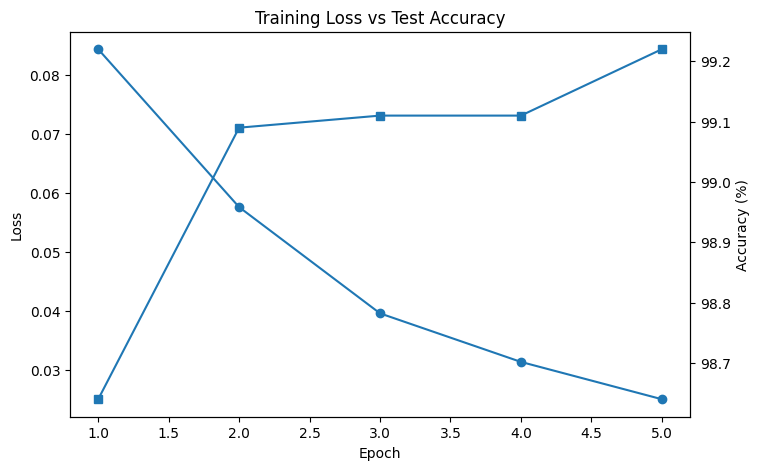

In [ ]:
epochs_range = range(1, epochs + 1)

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(
    epochs_range,
    train_losses,
    marker='o',
    label="Training Loss"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2 = ax1.twinx()

ax2.plot(
    epochs_range,
    test_accuracies,
    marker='s'
)

ax2.set_ylabel("Accuracy (%)")

plt.title("Training Loss vs Test Accuracy")

plt.show()

In [ ]:
loaded_model = Net().to(device)

loaded_model.load_state_dict(
    torch.load(
        "mnist_model.pt",
        map_location=device
    )
)

loaded_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


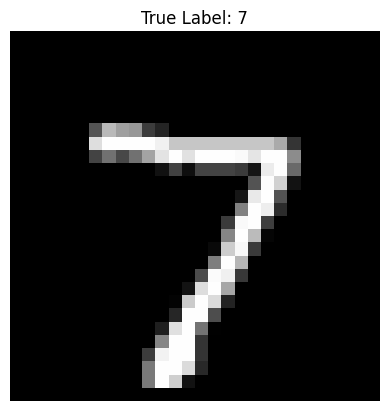

Predicted Label: 7
Actual Label: 7


In [ ]:
image, true_label = test_dataset[0]

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(f"True Label: {true_label}")
plt.axis("off")
plt.show()

input_image = image.unsqueeze(0).to(device)

with torch.no_grad():

    output = loaded_model(input_image)

    prediction = output.argmax(dim=1).item()

print("Predicted Label:", prediction)
print("Actual Label:", true_label)

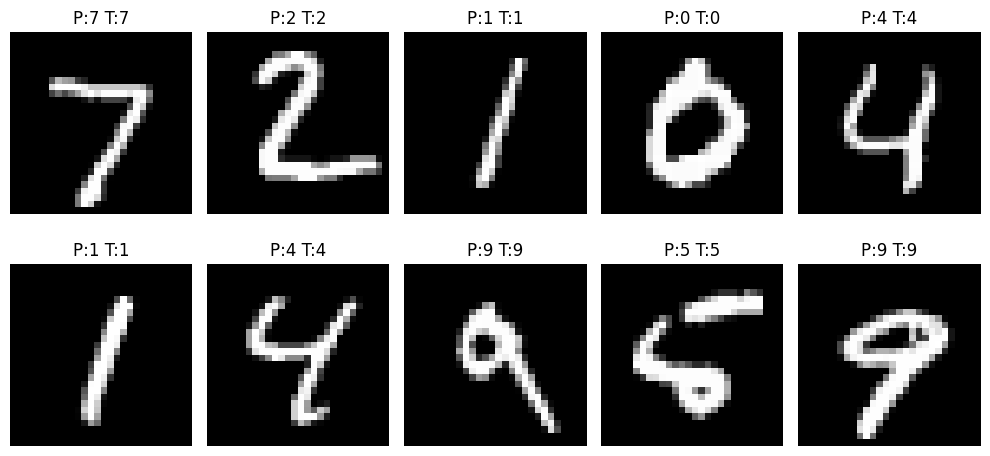

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(10):

    image, label = test_dataset[i]

    input_image = image.unsqueeze(0).to(device)

    with torch.no_grad():

        prediction = loaded_model(
            input_image
        ).argmax(dim=1).item()

    axes[i // 5, i % 5].imshow(
        image.squeeze(),
        cmap="gray"
    )

    axes[i // 5, i % 5].set_title(
        f"P:{prediction} T:{label}"
    )

    axes[i // 5, i % 5].axis("off")

plt.tight_layout()
plt.show()

# Reflections:


1.   The CNN architecture performed well on MNIST and achieved over 99% test accuracy. The model used two convolutional layers followed by fully connected layers and dropout for regularization.
CrossEntropyLoss was chosen because it is designed for multi-class classification problems and combines LogSoftmax with NLLLoss.
Adam optimizer was selected because it converges faster than standard SGD.
2.   Improvements :

*   improve by adding another convolutional layer to improve learning capacity
*   this also can be done by feature maps so more output channels from one layer to another so more detailed learning


*   more epochs
*   Augmentation - this could be done during training to truly test accuracy and randomise the training





